In [1]:
install.packages("marginaleffects")
install.packages("fastDummies")
install.packages("ggplot2")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



also installing the dependency ‘insight’




Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



also installing the dependencies ‘S7’, ‘scales’




In [2]:
library(tidyverse)
library(patchwork)
library(data.table)
library(MASS)
library(car)
library(ggfortify) # use autoplot(lm_model, which = 1:6, ncol = 2, label.size = 3)
library(lme4) #  Use boot_summary(lmer_model, type = "perc") from library(boot.pval) for p-values
library(mgcv) # use gam, gam.check(), plot(), plot_predictions()
library(earth) # use earth() model (MARS model)
library(marginaleffects)
library(fastDummies)

theme_custom <- theme_classic() +
                theme(## Axis labels
                      axis.text.y  = element_text(size=16, face="bold", color="#333333"),
                      axis.text.x  = element_text(size=20, color="#333333"),
                      ## Title, subtitle, caption, legend
                      plot.title   = element_text(size=26, face="bold", color="#333333"),
                      plot.subtitle = element_text(size=23, color="#333333"),
                      plot.caption = element_text(size=12, colour="#333333", hjust=0),
                      legend.position = "top",
                      legend.text = element_text(size=20),
                      legend.title = element_blank(),
                      legend.key.spacing.x = unit(1.0, "cm"),
                      axis.title.x = element_text(size=20, margin=margin(t=10,b=10)),
                      axis.title.y = element_text(size=20, margin=margin(l=10,r=10)),
                      strip.text = element_text(size=20),
                      ## axis lines
                      panel.grid.major.y = element_line(color="#6F8793"),
                      axis.ticks.y = element_blank(),
                      axis.ticks.x = element_blank(),
                     )
                     
figsize <- function(width=22, height=8){
    options(repr.plot.width=width, repr.plot.height=height)
}
figsize()
  

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.3     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘data.table’




The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year




The following objects are masked from ‘package:dplyr’:

    between, first, last




...

Loading required package: Formula



Loading required package: plotmo



Loading required package: plotrix




Attaching package: ‘marginaleffects’




The following object is masked from ‘package:lme4’:

    refit




# Reading and Processing Data

In [3]:
test = read_csv("/kaggle/input/competitions/playground-series-s6e6/test.csv")

Rows: 247435 Columns: 11


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): spectral_type, galaxy_population
dbl (9): id, alpha, delta, u, g, r, i, z, redshift



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [4]:
train = read_csv("/kaggle/input/competitions/playground-series-s6e6/train.csv")

train <- train %>%
    dplyr::select(!id)

train %>% head()

Rows: 577347 Columns: 12


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): spectral_type, galaxy_population, class
dbl (9): id, alpha, delta, u, g, r, i, z, redshift



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>
147.7343,16.95927,25.47212,21.89556,20.35793,19.25711,18.62106,0.40898227,M,Red_Sequence,GALAXY
127.9887,32.34672,20.77851,19.08706,17.58721,17.22607,16.78643,0.15797581,M,Red_Sequence,GALAXY
179.7926,35.34484,21.03520,21.07913,21.17184,20.58263,20.55737,2.82376996,O/B,Blue_Cloud,QSO
225.8183,48.56942,23.30506,21.05074,19.01775,18.36566,17.91495,0.53609865,M,Red_Sequence,GALAXY
141.8361,19.34285,21.70316,19.47168,18.23445,17.89945,17.61618,0.55576138,M,Red_Sequence,GALAXY
250.7279,31.75655,20.92647,19.69348,18.90236,19.24757,18.50824,0.07629877,G/K,Blue_Cloud,STAR


#### No NA values

In [5]:
train %>% 
    is.na() %>%
    apply(2, sum) %>%
    data.frame() %>%
    rename("train_NA_count"=".")

,train_NA_count
,<int>
alpha,0
delta,0
u,0
g,0
r,0
i,0
z,0
redshift,0
spectral_type,0


In [6]:
test %>% 
    is.na() %>%
    apply(2, sum) %>%
    data.frame() %>%
    rename("test_NA_count"=".")

,test_NA_count
,<int>
id,0
alpha,0
delta,0
u,0
g,0
r,0
i,0
z,0
redshift,0


#### No duplicated entries

In [7]:
train %>% duplicated() %>% sum()

[1] 0

## Analyzing Train Data's Numerical Features

In [8]:
num_df <- 
    train %>%
    dplyr::select(where(is.numeric), class)

num_df <- dummy_cols(num_df) %>% dplyr::select(!class)

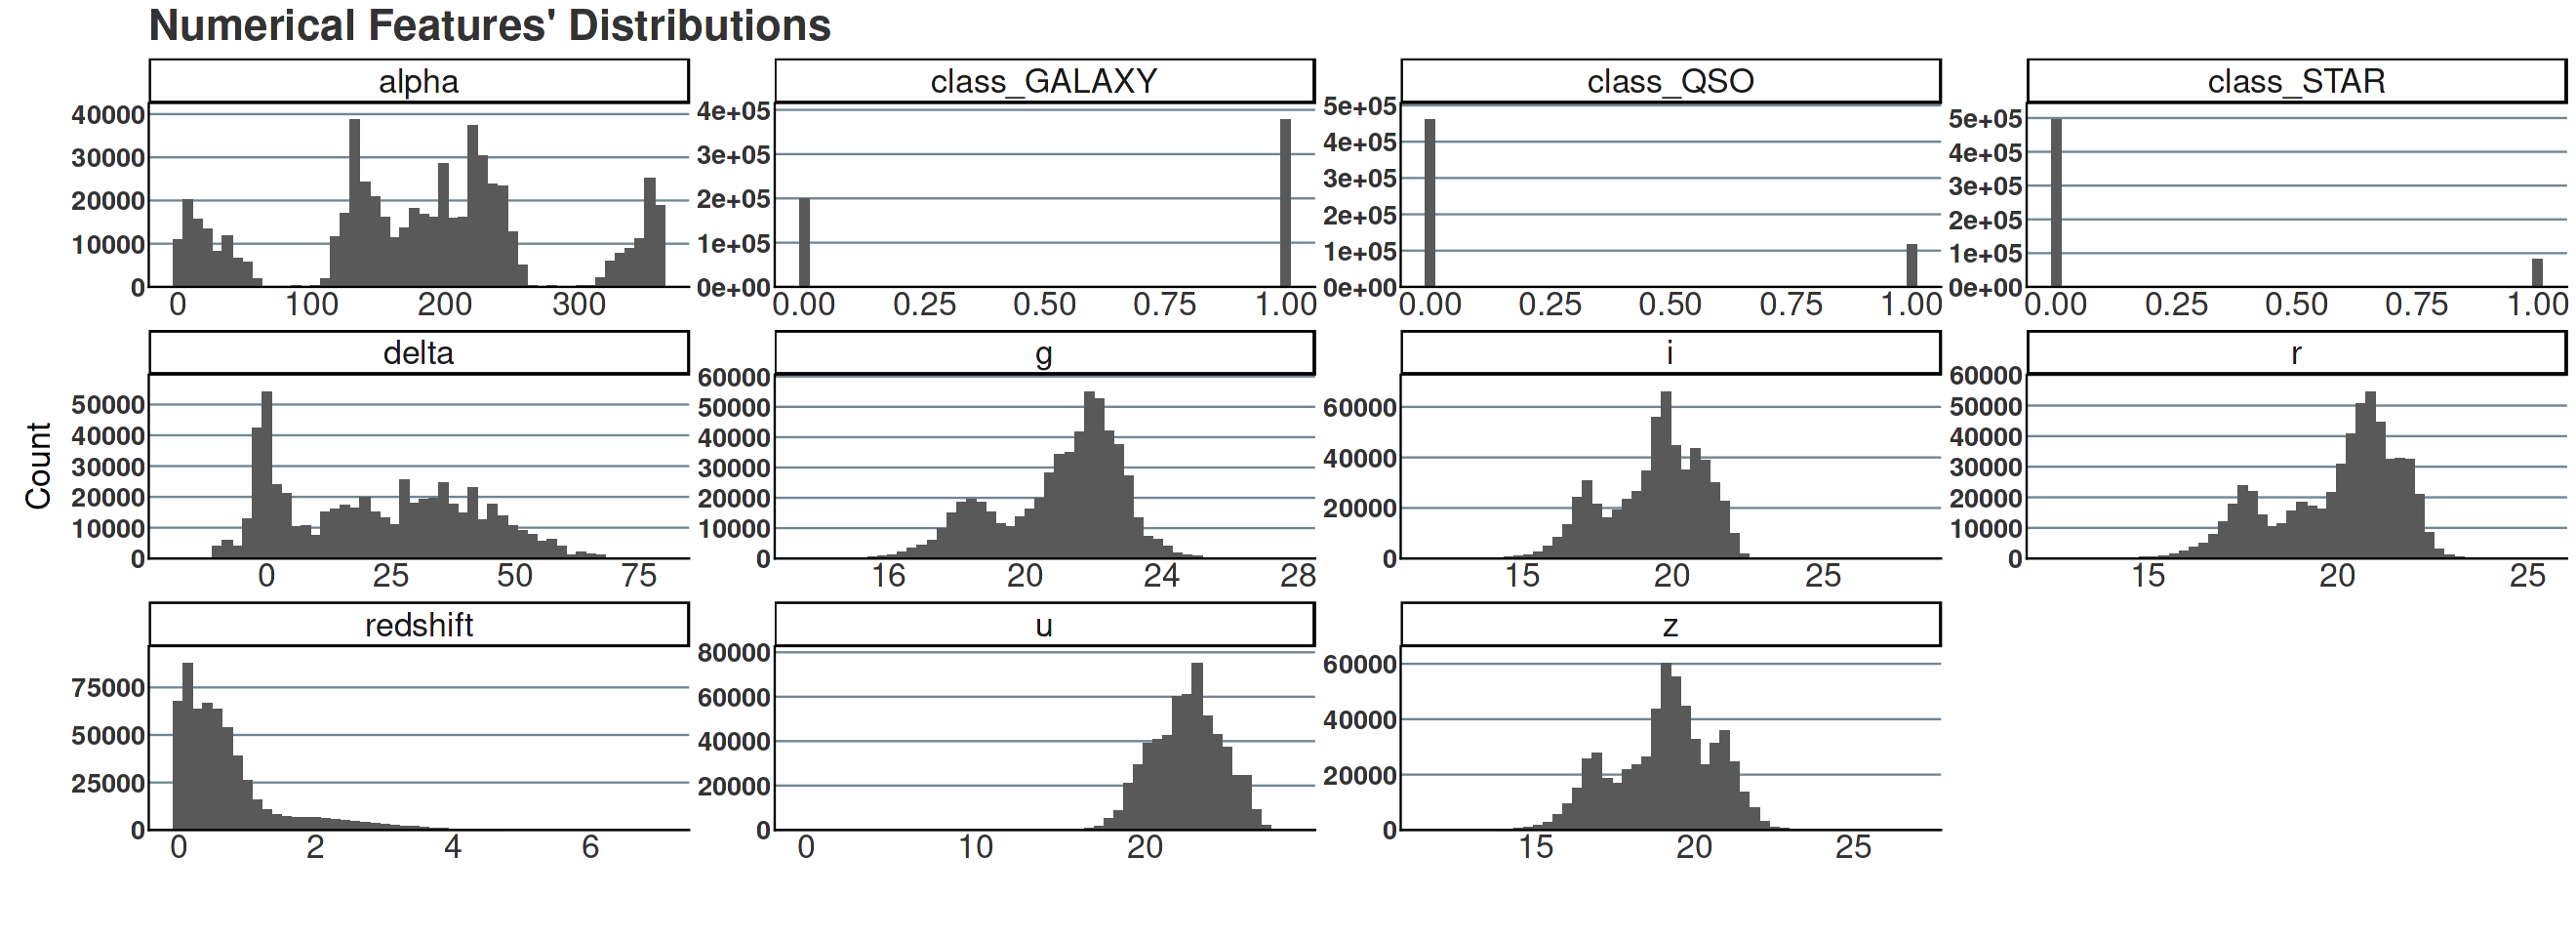

In [9]:
num_df %>% 
    pivot_longer(
        cols = 1:11, names_to="feature"
    ) %>%
    ggplot(aes(x=value)) +
    geom_histogram(bins=50) +
    facet_wrap(~feature, scales="free") +
    labs(title="Numerical Features' Distributions", x="", y="Count") +
    scale_y_continuous(expand=expansion(mult=c(0,.1))) +
    theme_custom 

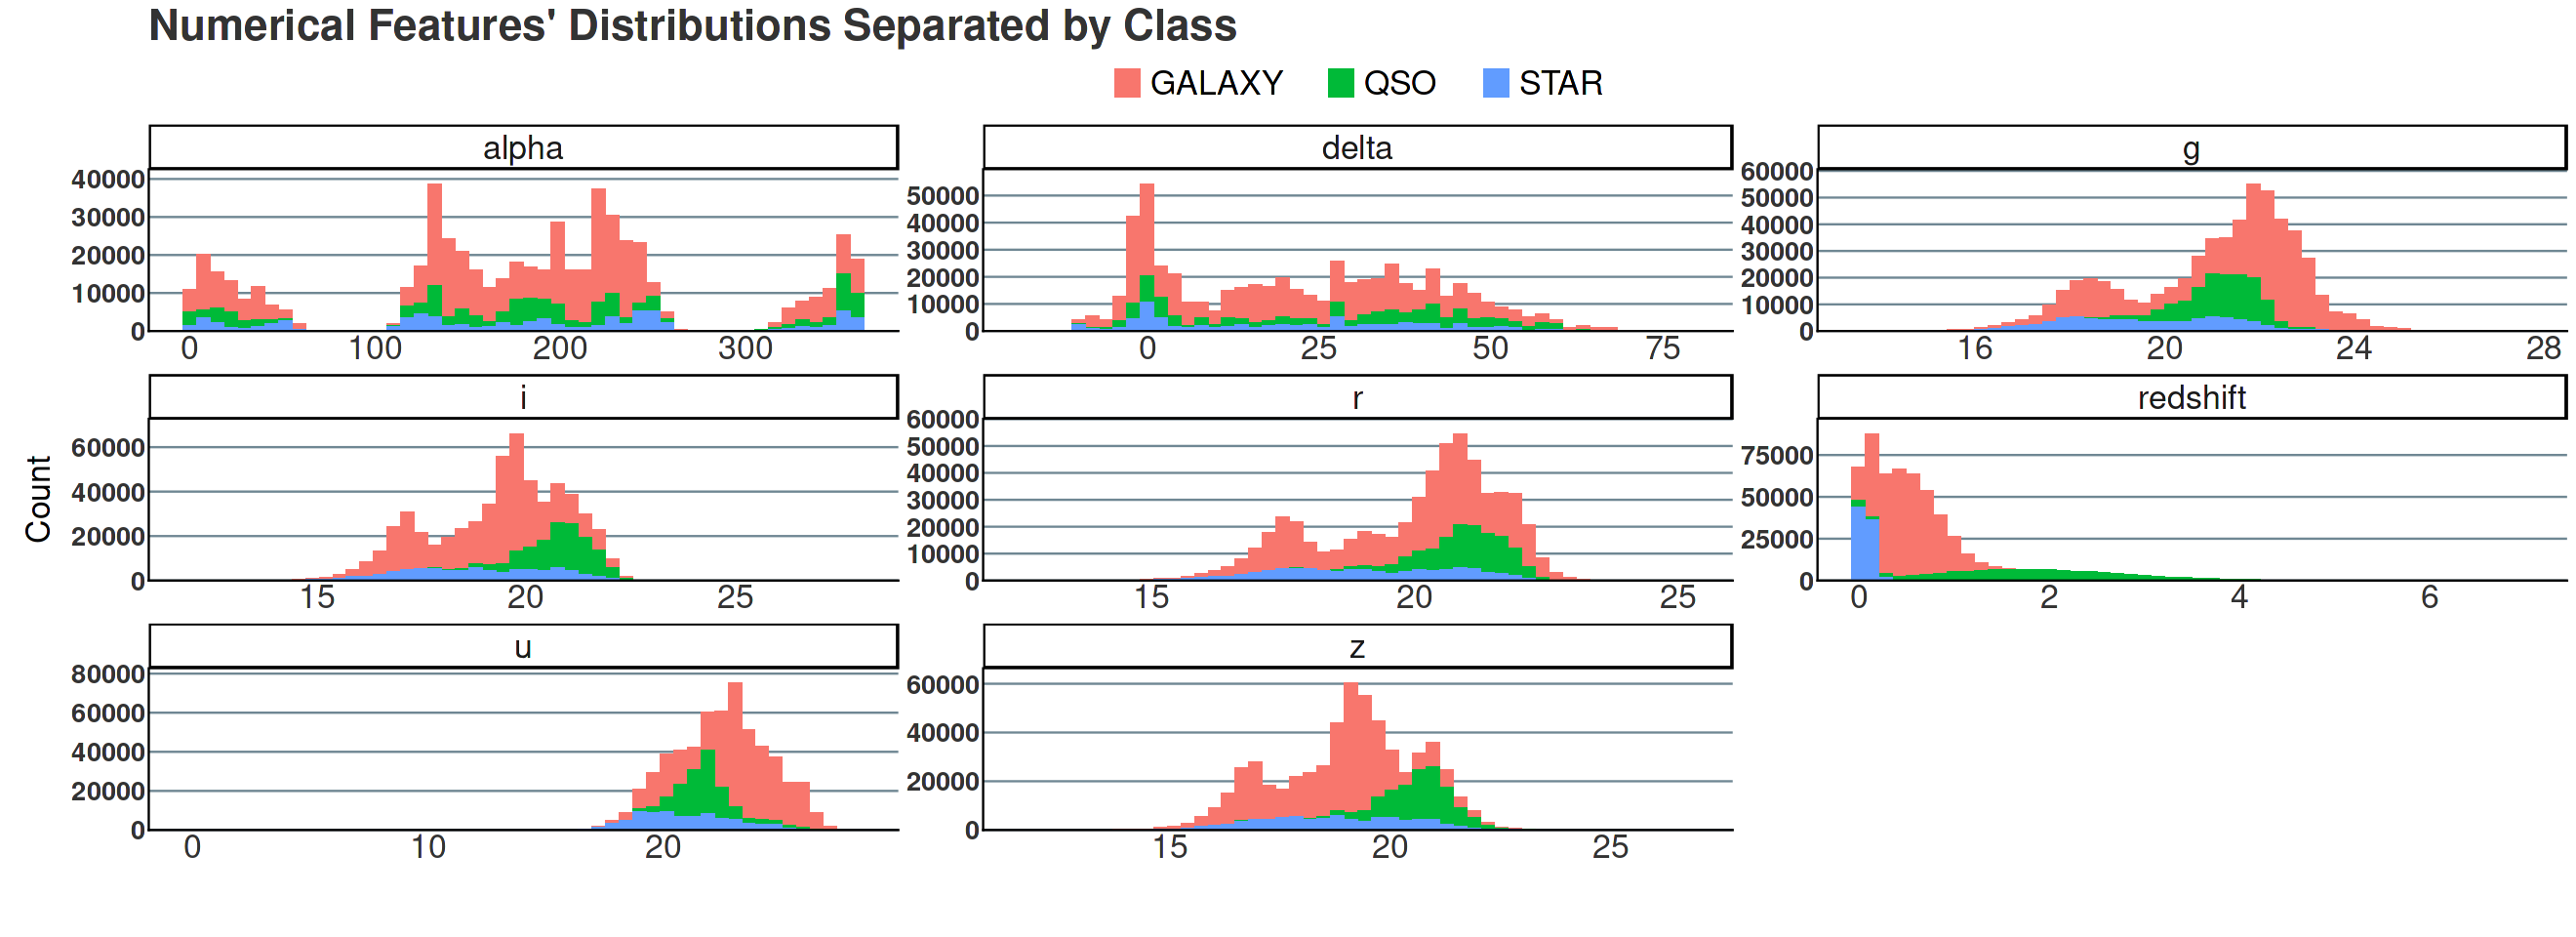

In [10]:
num_df_new <- 
    train %>%
    dplyr::select(where(is.numeric), class)

num_df_new %>%
    pivot_longer(cols=-class, names_to="feature") %>%
    ggplot(aes(x=value, fill=class)) +
    geom_histogram(bins=50) +
    facet_wrap(~feature, scales="free") +
    labs(title="Numerical Features' Distributions Separated by Class", x="", y="Count") +
    scale_y_continuous(expand=expansion(mult=c(0,.1))) +
    theme_custom 

`geom_smooth()` using formula = 'y ~ x'


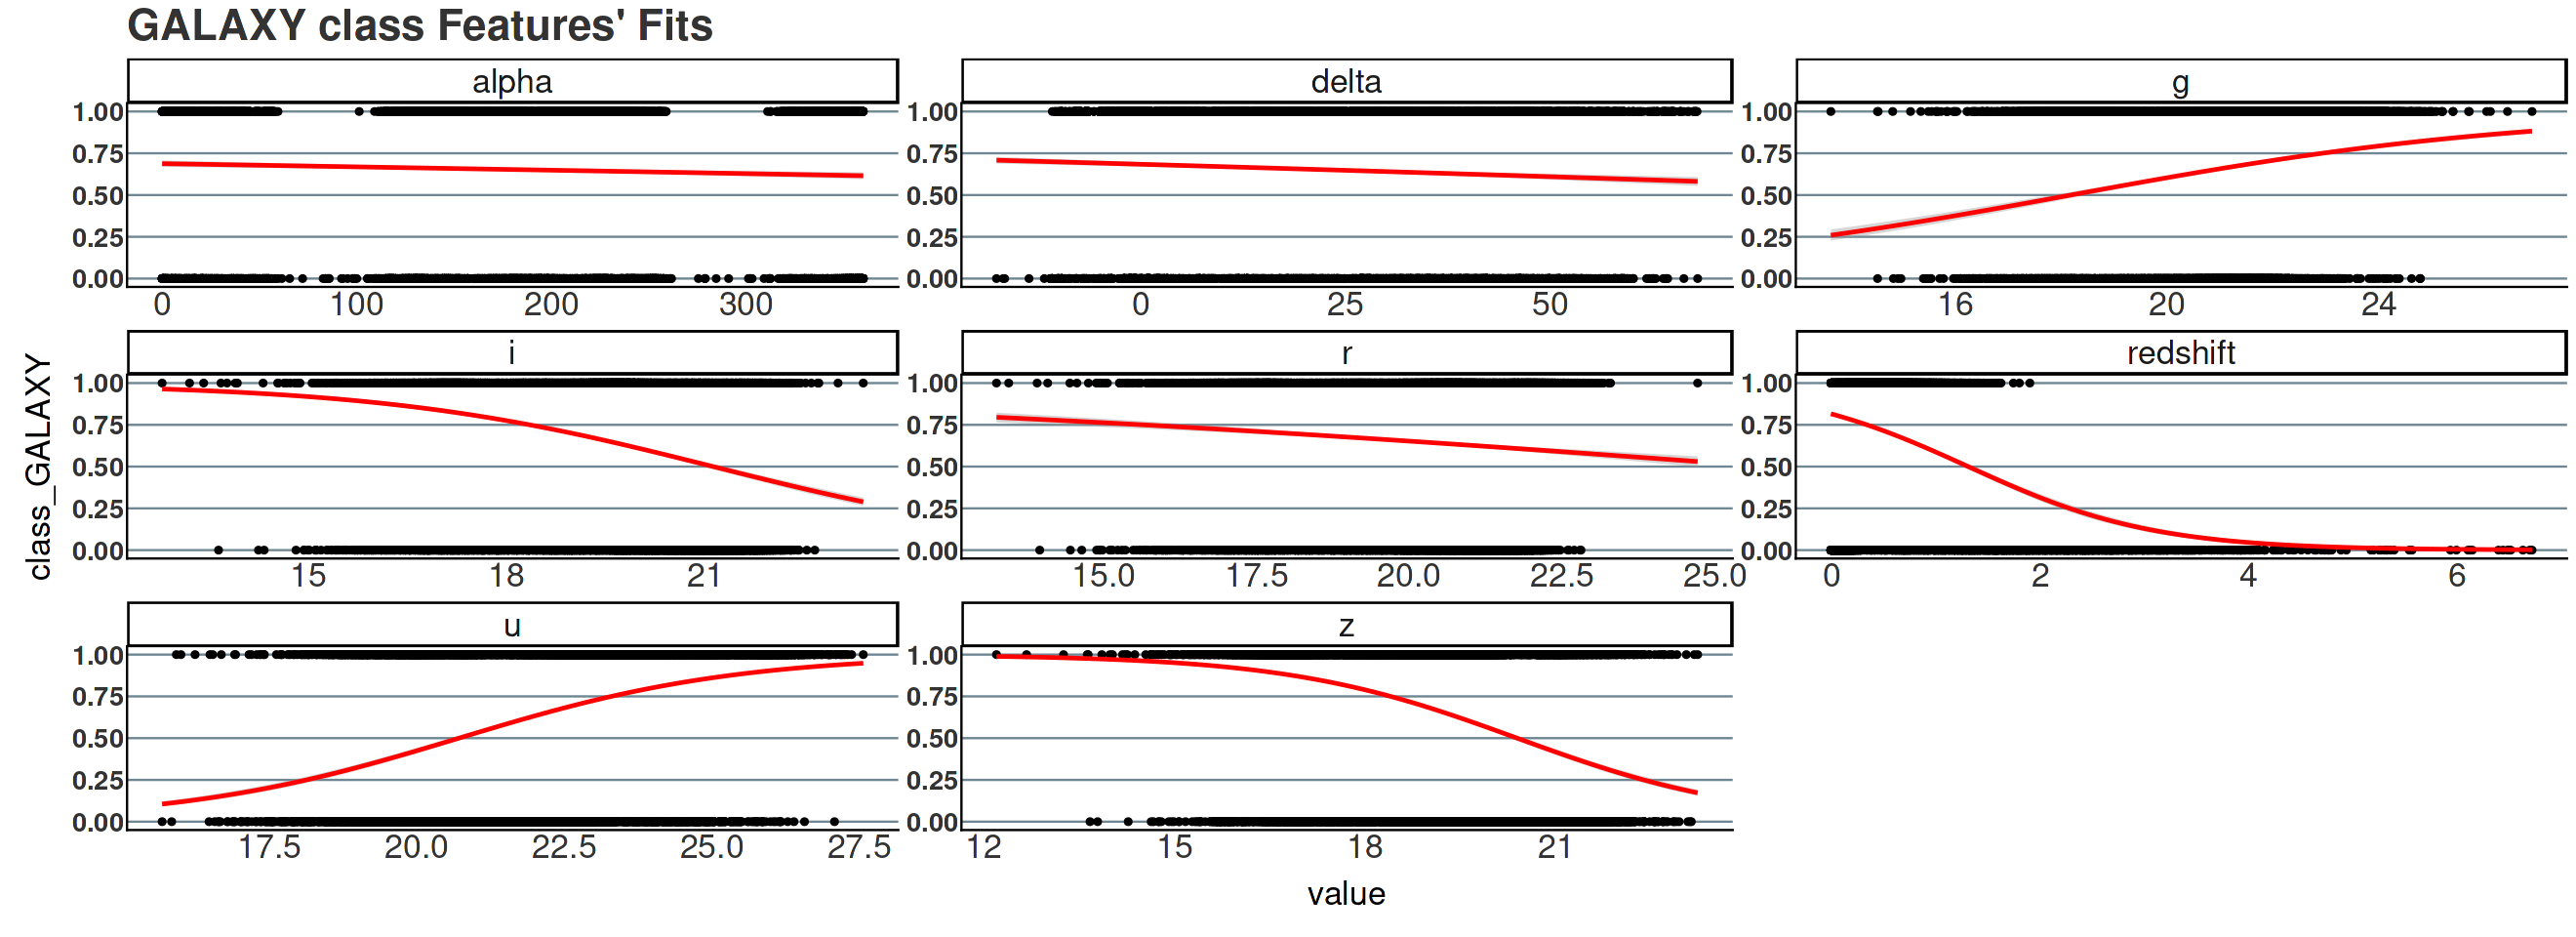

In [11]:
num_df %>%
    dplyr::select(!c("class_QSO", "class_STAR")) %>%
    slice_sample(n=10000) %>%
    pivot_longer(cols=-class_GALAXY, names_to="feature") %>%
    ggplot(aes(x=value, y=class_GALAXY)) +
    geom_point() + 
    geom_smooth(method="glm", method.args=list(family=binomial), color="red") +
    facet_wrap(~feature, scales="free") +
    labs(title="GALAXY class Features' Fits") +
    theme_custom

`geom_smooth()` using formula = 'y ~ x'


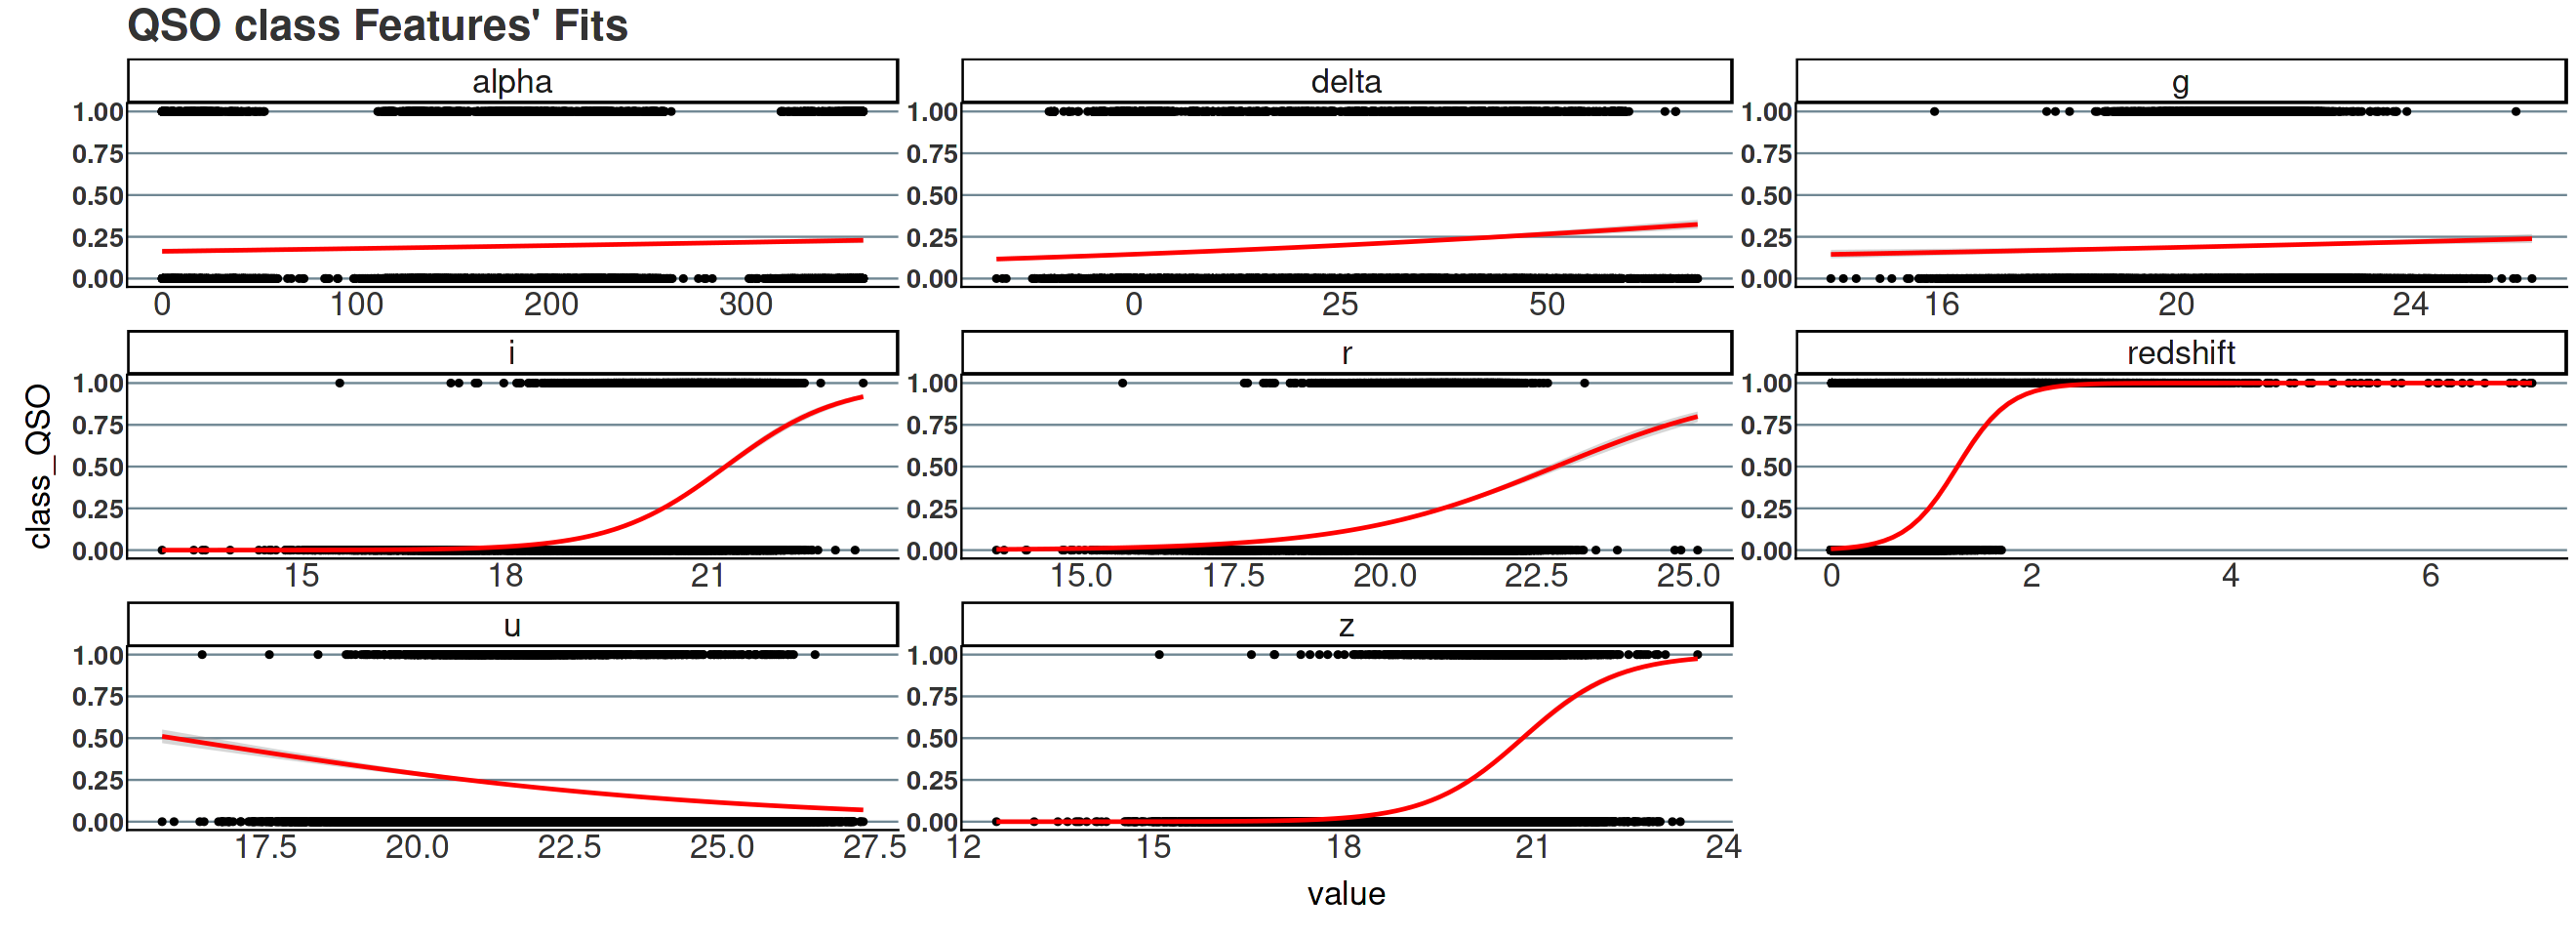

In [12]:
num_df %>%
    dplyr::select(!c("class_GALAXY", "class_STAR")) %>%
    slice_sample(n=10000) %>%
    pivot_longer(cols=-class_QSO, names_to="feature") %>%
    ggplot(aes(x=value, y=class_QSO)) +
    geom_point() + 
    geom_smooth(method="glm", method.args=list(family=binomial), color="red") +
    facet_wrap(~feature, scales="free") +
    labs(title="QSO class Features' Fits") +
    theme_custom

`geom_smooth()` using formula = 'y ~ x'


Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


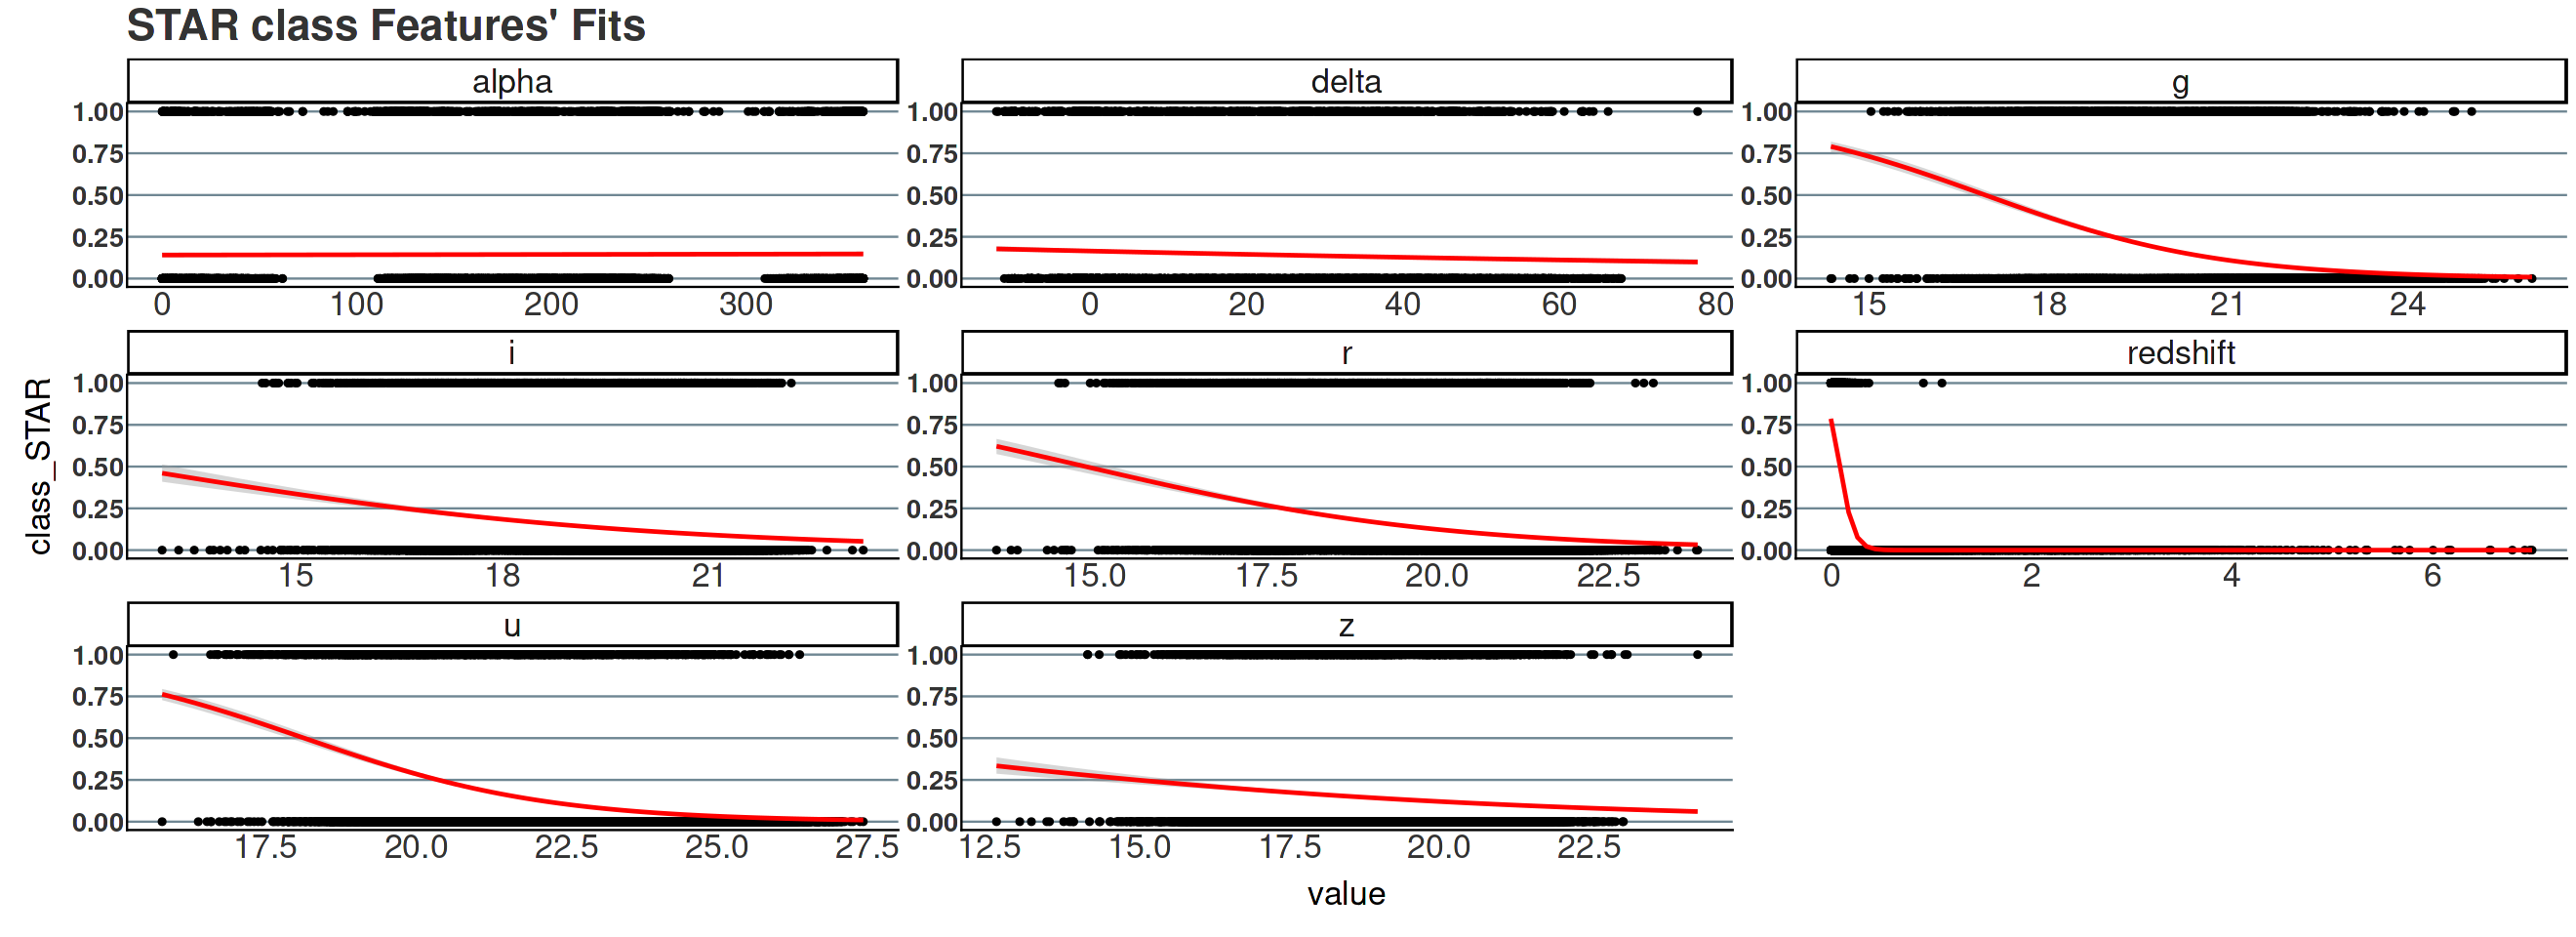

In [13]:
num_df %>%
    dplyr::select(!c("class_QSO", "class_GALAXY")) %>%
    slice_sample(n=10000) %>%
    pivot_longer(cols=-class_STAR, names_to="feature") %>%
    ggplot(aes(x=value, y=class_STAR)) +
    geom_point() + 
    geom_smooth(method="glm", method.args=list(family=binomial), color="red") +
    facet_wrap(~feature, scales="free") +
    labs(title="STAR class Features' Fits") +
    theme_custom

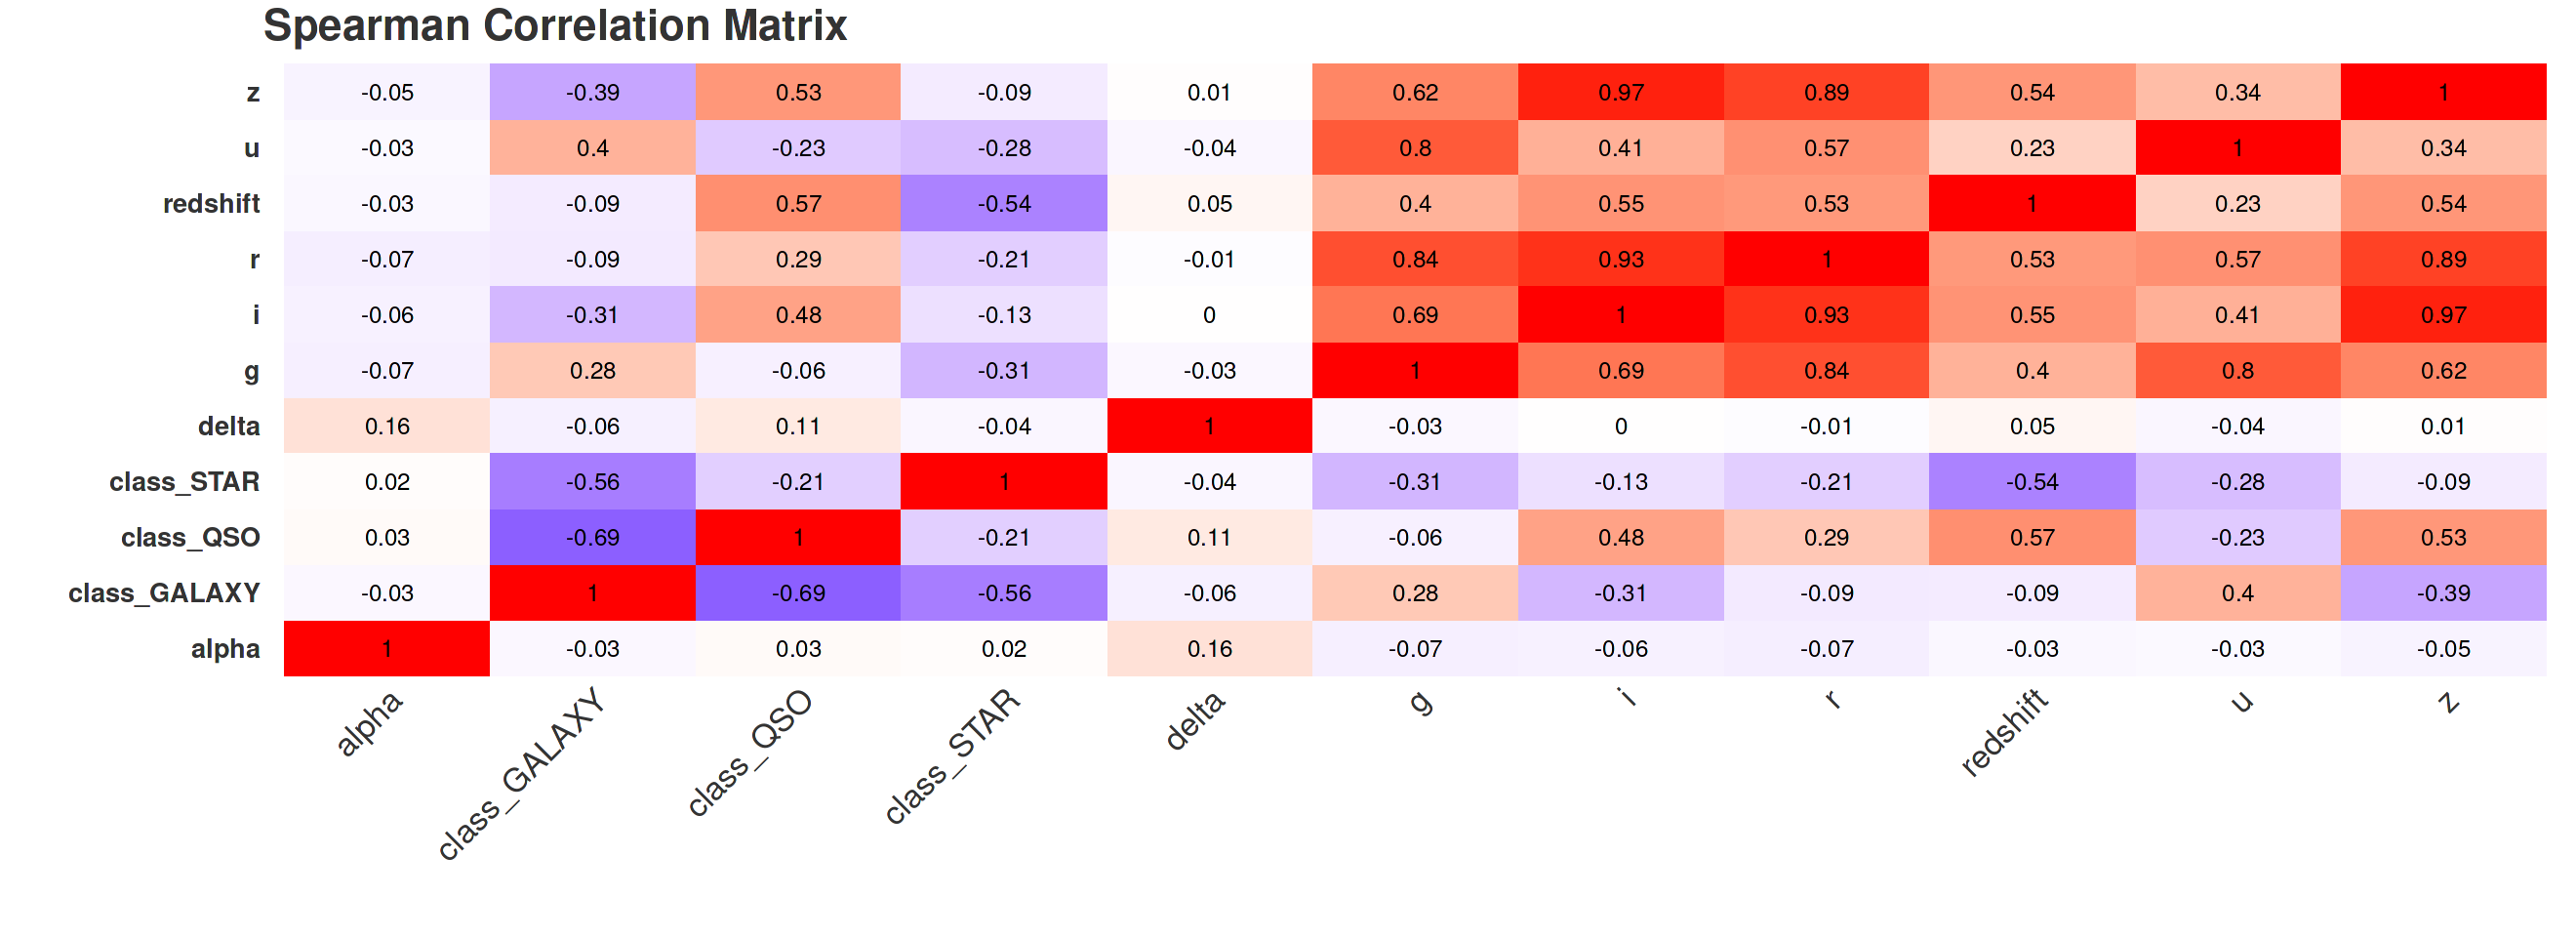

In [14]:
num_df %>%
    cor(method="spearman") %>%
    data.frame() %>%
    rownames_to_column() %>%
    pivot_longer(cols=-rowname, names_to="feature", values_to="corr") %>%
    ggplot(aes(x=rowname, y=feature, fill=corr)) +
    geom_tile() +
    geom_text(aes(label=round(corr, 2)), size=5) +
    scale_fill_gradient2(low="blue", mid="white", high="red") +
    labs(x="", y="", title="Spearman Correlation Matrix") +
    theme_custom +
    theme(
        legend.position="none",
        axis.line.x=element_blank(),
        axis.line.y=element_blank(),
        panel.grid.major.y=element_blank(),
        axis.text.x=element_text(angle=45, hjust=1, vjust=1)
    )

# Evaluating GAM Models

In [15]:
train_df <- dummy_cols(train, select_columns=c("class")) %>% dplyr::select(!class)

## Fast GAM model for GALAXY class
gam_galaxy <- bam(
    class_GALAXY ~
    spectral_type + galaxy_population + 
    s(alpha) + s(delta) + s(u) +
    s(g) + s(r) + s(i) + s(z) + 
    s(redshift)
    -class_QSO -class_STAR, 
    
    data=train_df,
    family=binomial(),
    discrete=TRUE
)

## Fast GAM model for QSO class
gam_qso <- bam(
    class_QSO ~
    spectral_type + galaxy_population +
    s(alpha) + s(delta) + s(u) +
    s(g) + s(r) + s(i) + s(z) + 
    s(redshift)
    -class_GALAXY -class_STAR, 
    
    data=train_df,
    family=binomial(),
    discrete=TRUE
)

## Fast GAM model for STAR class
gam_star <- bam(
    class_STAR ~
    spectral_type + galaxy_population +
    s(alpha) + s(delta) + s(u) +
    s(g) + s(r) + s(i) + s(z) + 
    s(redshift)
    -class_QSO -class_GALAXY, 
    
    data=train_df,
    family=binomial(),
    discrete=TRUE
)

Warning message in bgam.fitd(G, mf, gp, scale, nobs.extra = 0, rho = rho, coef = coef, :
“fitted probabilities numerically 0 or 1 occurred”


Warning message in bgam.fitd(G, mf, gp, scale, nobs.extra = 0, rho = rho, coef = coef, :
“fitted probabilities numerically 0 or 1 occurred”


Warning message in bgam.fitd(G, mf, gp, scale, nobs.extra = 0, rho = rho, coef = coef, :
“fitted probabilities numerically 0 or 1 occurred”


In [16]:
gam_galaxy %>% summary()


Family: binomial 
Link function: logit 

Formula:
class_GALAXY ~ spectral_type + galaxy_population + s(alpha) + 
    s(delta) + s(u) + s(g) + s(r) + s(i) + s(z) + s(redshift) - 
    class_QSO - class_STAR

Parametric coefficients:
                                Estimate Std. Error z value Pr(>|z|)    
(Intercept)                   -744.96957   19.16607 -38.869  < 2e-16 ***
spectral_typeG/K                 0.07546    0.02450   3.079  0.00207 ** 
spectral_typeM                  -0.03959    0.04380  -0.904  0.36611    
spectral_typeO/B                 0.07609    0.03655   2.082  0.03733 *  
galaxy_populationRed_Sequence   -0.04796    0.02780  -1.725  0.08451 .  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Approximate significance of smooth terms:
              edf Ref.df Chi.sq p-value    
s(alpha)    8.995  9.000   9897  <2e-16 ***
s(delta)    8.946  8.999   2309  <2e-16 ***
s(u)        8.848  8.982   4245  <2e-16 ***
s(g)        8.749  8.971   7130  <2e-16 ***


In [17]:
gam_qso %>% summary()


Family: binomial 
Link function: logit 

Formula:
class_QSO ~ spectral_type + galaxy_population + s(alpha) + s(delta) + 
    s(u) + s(g) + s(r) + s(i) + s(z) + s(redshift) - class_GALAXY - 
    class_STAR

Parametric coefficients:
                              Estimate Std. Error z value Pr(>|z|)    
(Intercept)                   19.94898    7.60751   2.622  0.00873 ** 
spectral_typeG/K               0.05832    0.03561   1.638  0.10149    
spectral_typeM                -0.01639    0.07705  -0.213  0.83152    
spectral_typeO/B              -0.01169    0.03901  -0.300  0.76436    
galaxy_populationRed_Sequence  0.33691    0.06283   5.362 8.22e-08 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Approximate significance of smooth terms:
              edf Ref.df  Chi.sq p-value    
s(alpha)    8.629  8.945  1592.4  <2e-16 ***
s(delta)    8.777  8.969  1932.9  <2e-16 ***
s(u)        8.333  8.743 12545.4  <2e-16 ***
s(g)        8.477  8.803  4216.0  <2e-16 ***
s(r)   

In [18]:
gam_star %>% summary()


Family: binomial 
Link function: logit 

Formula:
class_STAR ~ spectral_type + galaxy_population + s(alpha) + s(delta) + 
    s(u) + s(g) + s(r) + s(i) + s(z) + s(redshift) - class_QSO - 
    class_GALAXY

Parametric coefficients:
                                Estimate Std. Error z value Pr(>|z|)    
(Intercept)                   -1.291e+04  4.968e+02 -25.977  < 2e-16 ***
spectral_typeG/K               4.225e-01  2.764e-02  15.285  < 2e-16 ***
spectral_typeM                 3.355e-01  4.940e-02   6.791 1.12e-11 ***
spectral_typeO/B              -8.806e-01  3.890e-02 -22.636  < 2e-16 ***
galaxy_populationRed_Sequence -6.243e-01  3.006e-02 -20.771  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Approximate significance of smooth terms:
               edf Ref.df  Chi.sq p-value    
s(alpha)     8.995  9.000  8128.0  <2e-16 ***
s(delta)     8.818  8.983   808.8  <2e-16 ***
s(u)         8.910  8.991  8635.0  <2e-16 ***
s(g)         8.808  8.982  9607.0  <